<a href="https://colab.research.google.com/github/marinmejiajuanesteban-lang/Trabajo_final/blob/main/Trabajo_final_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **BASE DE DATOS SOBRE LA EL IMPACTO DE LA IA EN EL EMPLEO Y LOS SALARIOS** ##

In [44]:
# importamos las librerias necesarios que vamos a usar en este analisis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# estas son las libreria a usar en el analisis de datos.
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA


In [3]:
# Importamos la base de datos que vamos a usar para este analisis que lo tenemos en archivo csv
from google.colab import files
uploaded = files.upload()



Saving Future of Jobs AI Dataset.csv to Future of Jobs AI Dataset.csv


In [4]:
futuro_IA = pd.read_csv("Future of Jobs AI Dataset.csv")


In [5]:
# Verificamos que la base de datos de haya cargado de manera correcta

futuro_IA.head()

,job_title,country,experience_level,education_level,year,salary,ai_risk_score,primary_skill,skill_demand_score,job_openings,job_survival_class,salary_bucket,ai_risk_category
0,Data Scientist,USA,Senior,Master,2022,61931.03,0.32,Python,88,39158,2,High,Medium Risk
1,Software Engineer,India,Senior,Bachelor,2032,21330.84,0.52,Java,80,7265,1,High,Medium Risk
2,Data Scientist,Canada,Mid,Bachelor,2015,24211.17,0.25,Python,70,22962,1,High,Low Risk
3,Data Scientist,India,Entry,PhD,2034,11794.86,0.44,Python,95,17023,1,Medium,Medium Risk
4,Data Analyst,Canada,Entry,PhD,2035,17999.26,0.75,SQL,61,3433,0,Medium,High Risk


## **DESCRIPCION DE LOS DATOS** ##

In [6]:
futuro_IA.head()

,job_title,country,experience_level,education_level,year,salary,ai_risk_score,primary_skill,skill_demand_score,job_openings,job_survival_class,salary_bucket,ai_risk_category
0,Data Scientist,USA,Senior,Master,2022,61931.03,0.32,Python,88,39158,2,High,Medium Risk
1,Software Engineer,India,Senior,Bachelor,2032,21330.84,0.52,Java,80,7265,1,High,Medium Risk
2,Data Scientist,Canada,Mid,Bachelor,2015,24211.17,0.25,Python,70,22962,1,High,Low Risk
3,Data Scientist,India,Entry,PhD,2034,11794.86,0.44,Python,95,17023,1,Medium,Medium Risk
4,Data Analyst,Canada,Entry,PhD,2035,17999.26,0.75,SQL,61,3433,0,Medium,High Risk


In [7]:
futuro_IA.shape

(12343, 13)

In [8]:
futuro_IA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12343 entries, 0 to 12342
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job_title           12343 non-null  object 
 1   country             12343 non-null  object 
 2   experience_level    12343 non-null  object 
 3   education_level     12343 non-null  object 
 4   year                12343 non-null  int64  
 5   salary              12343 non-null  float64
 6   ai_risk_score       12343 non-null  float64
 7   primary_skill       12343 non-null  object 
 8   skill_demand_score  12343 non-null  int64  
 9   job_openings        12343 non-null  int64  
 10  job_survival_class  12343 non-null  int64  
 11  salary_bucket       12343 non-null  object 
 12  ai_risk_category    12343 non-null  object 
dtypes: float64(2), int64(4), object(7)
memory usage: 1.2+ MB


Se realizó una exploración inicial del dataset con el fin de comprender su estructura general.
El conjunto de datos cuenta con 12.343 registros y 13 variables, lo que permite un análisis suficientemente robusto.

A través del método .info(), se identificaron los tipos de datos de cada columna, evidenciando la presencia de variables tanto numéricas como categóricas.
Esta revisión es fundamental para detectar posibles inconsistencias en los tipos de datos antes de proceder con el análisis.

In [9]:
futuro_IA = futuro_IA.rename(columns={
    "job_title": "puesto_trabajo",
    "country": "pais",
    "experience_level": "nivel_experiencia",
    "education_level": "nivel_educacion",
    "year": "anio",
    "salary": "salario_usd",
    "ai_risk_score": "probabilidad_riesgo_ia",
    "primary_skill": "habilidad_principal",
    "skill_demand_score": "demanda_habilidad",
    "job_openings": "vacantes",
    "job_survival_class": "estabilidad_laboral",
    "salary_bucket": "nivel_salario",
    "ai_risk_category": "nivel_riesgo_ia"
})

In [10]:
futuro_IA.head()

,puesto_trabajo,pais,nivel_experiencia,nivel_educacion,anio,salario_usd,probabilidad_riesgo_ia,habilidad_principal,demanda_habilidad,vacantes,estabilidad_laboral,nivel_salario,nivel_riesgo_ia
0,Data Scientist,USA,Senior,Master,2022,61931.03,0.32,Python,88,39158,2,High,Medium Risk
1,Software Engineer,India,Senior,Bachelor,2032,21330.84,0.52,Java,80,7265,1,High,Medium Risk
2,Data Scientist,Canada,Mid,Bachelor,2015,24211.17,0.25,Python,70,22962,1,High,Low Risk
3,Data Scientist,India,Entry,PhD,2034,11794.86,0.44,Python,95,17023,1,Medium,Medium Risk
4,Data Analyst,Canada,Entry,PhD,2035,17999.26,0.75,SQL,61,3433,0,Medium,High Risk


Se realizó la traducción y estandarización de los nombres de las variables a español, con el objetivo de mejorar la comprensión del dataset y facilitar su interpretación desde una perspectiva de negocio.

Los nuevos nombres permiten identificar de forma más intuitiva el significado de cada variable, lo que contribuye a un análisis más claro y una mejor comunicación de los resultados.

In [11]:
futuro_IA.isnull().sum()

,0
puesto_trabajo,0
pais,0
nivel_experiencia,0
nivel_educacion,0
anio,0
salario_usd,0
probabilidad_riesgo_ia,0
habilidad_principal,0
demanda_habilidad,0
vacantes,0


Se realizó la verificación de valores faltantes en el dataset.
No se identificaron valores nulos en ninguna de las columnas, lo cual indica una alta calidad inicial de los datos y permite continuar con el análisis sin necesidad de imputaciones o eliminación de registros.

In [12]:
futuro_IA.duplicated().sum()

np.int64(0)

Se evaluó la presencia de registros duplicados dentro del dataset.
No se encontraron duplicados, lo que garantiza que cada fila representa una observación única.

In [13]:
futuro_IA.dtypes

,0
puesto_trabajo,object
pais,object
nivel_experiencia,object
nivel_educacion,object
anio,int64
salario_usd,float64
probabilidad_riesgo_ia,float64
habilidad_principal,object
demanda_habilidad,int64
vacantes,int64


Se revisaron los tipos de datos de cada variable para asegurar su correcta interpretación.
Las variables categóricas se encuentran en formato str, mientras que las variables numéricas están correctamente tipadas como int o float.
Esta validación es importante para garantizar que los análisis posteriores (estadísticos y gráficos) sean adecuados.

In [14]:
for col in futuro_IA.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(futuro_IA[col].unique())


puesto_trabajo:
['Data Scientist' 'Software Engineer' 'Data Analyst' 'DevOps Engineer'
 'Cybersecurity Analyst' 'Cloud Engineer' 'Business Analyst'
 'AI Researcher' 'ML Engineer' 'Product Manager']

pais:
['USA' 'India' 'Canada' 'UK' 'Germany' 'Australia']

nivel_experiencia:
['Senior' 'Mid' 'Entry']

nivel_educacion:
['Master' 'Bachelor' 'PhD']

habilidad_principal:
['Python' 'Java' 'SQL' 'Docker' 'Security' 'AWS' 'Excel' 'Deep Learning'
 'Strategy']

nivel_salario:
['High' 'Medium' 'Low']

nivel_riesgo_ia:
['Medium Risk' 'Low Risk' 'High Risk']


Se realizó una revisión de las variables categóricas para identificar posibles inconsistencias en los valores, tales como diferencias en mayúsculas, espacios en blanco o categorías duplicadas.
Este paso es clave para evitar errores en el análisis y garantizar la correcta agrupación de los datos.

Se evidencia que no tenemos variables categoricas fuera del estandar conocido.

In [15]:
futuro_IA.describe()

,anio,salario_usd,probabilidad_riesgo_ia,demanda_habilidad,vacantes,estabilidad_laboral
count,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000
mean,2025.054525,34553.729166,0.396008,79.453374,25223.652029,1.310054
std,6.058714,18024.702961,0.187665,11.483535,14163.309081,0.658417
min,2015.000000,3875.170000,0.050000,60.000000,1002.000000,0.000000
25%,2020.000000,21331.405000,0.260000,70.000000,12993.000000,1.000000
50%,2025.000000,31573.380000,0.360000,79.000000,24896.000000,1.000000
75%,2030.000000,45307.845000,0.490000,89.000000,37440.500000,2.000000
max,2035.000000,113589.260000,0.850000,99.000000,49998.000000,2.000000


Se realizó un análisis descriptivo de las variables numéricas del dataset con el objetivo de identificar posibles valores atípicos o inconsistencias.

A través de medidas como la media, desviación estándar, valores mínimos y máximos, se evaluó la coherencia de los datos, permitiendo detectar posibles errores o valores extremos que puedan afectar el análisis.

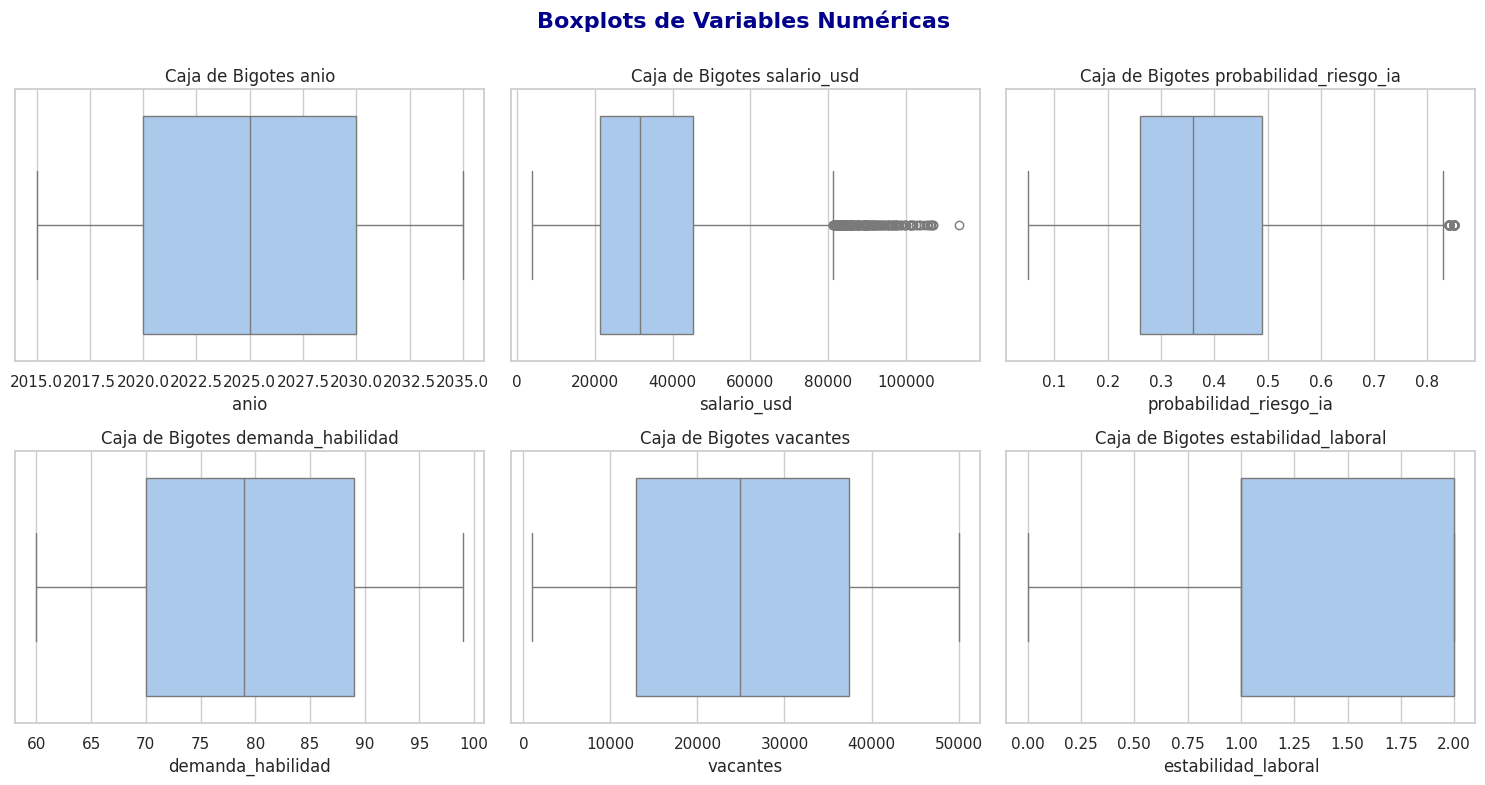

In [16]:
# columnas numéricas
cols = futuro_IA.select_dtypes(include=['int64', 'float64']).columns

# estilo pastel
sns.set(style="whitegrid", palette="pastel")

# crear lienzo 3x2
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# graficar
for i, col in enumerate(cols):
    sns.boxplot(x=futuro_IA[col], ax=axes[i])
    axes[i].set_title(f'Caja de Bigotes {col}')

# título general del gráfico
fig.suptitle(
    'Boxplots de Variables Numéricas',
    fontsize=16,
    fontweight='bold',
    color='darkblue'
)

# ajustar espacios
plt.tight_layout()

# ajustar posición del título para que no se encime
plt.subplots_adjust(top=0.88)

plt.show()

A partir del análisis exploratorio mediante diagramas de caja, se evaluó la distribución de las principales variables numéricas del dataset.

Se identificó que variables como el salario y las vacantes presentan una alta dispersión, lo que evidencia diferencias significativas dentro del mercado laboral analizado. En particular, el salario muestra una distribución sesgada hacia valores altos, indicando la existencia de algunos empleos con remuneraciones considerablemente superiores al promedio.

Por otro lado, variables como la demanda de habilidades y la probabilidad de riesgo por inteligencia artificial presentan distribuciones más concentradas, lo que sugiere comportamientos más homogéneos entre los distintos roles.

Finalmente, se observó que algunas variables, como la estabilidad laboral, corresponden a categorías discretas, por lo que su análisis requiere enfoques diferentes a los utilizados para variables continuas.

El mercado laboral analizado presenta una alta variabilidad en términos salariales, donde unos pocos empleos concentran los salarios más altos, mientras que la mayoría se mantiene en rangos medios, lo que evidencia una distribución desigual de ingresos.

Aunque la demanda de habilidades es relativamente alta y homogénea, el riesgo de automatización varía entre los distintos roles, lo que sugiere que no todos los empleos tienen el mismo nivel de exposición frente al avance de la inteligencia artificial.

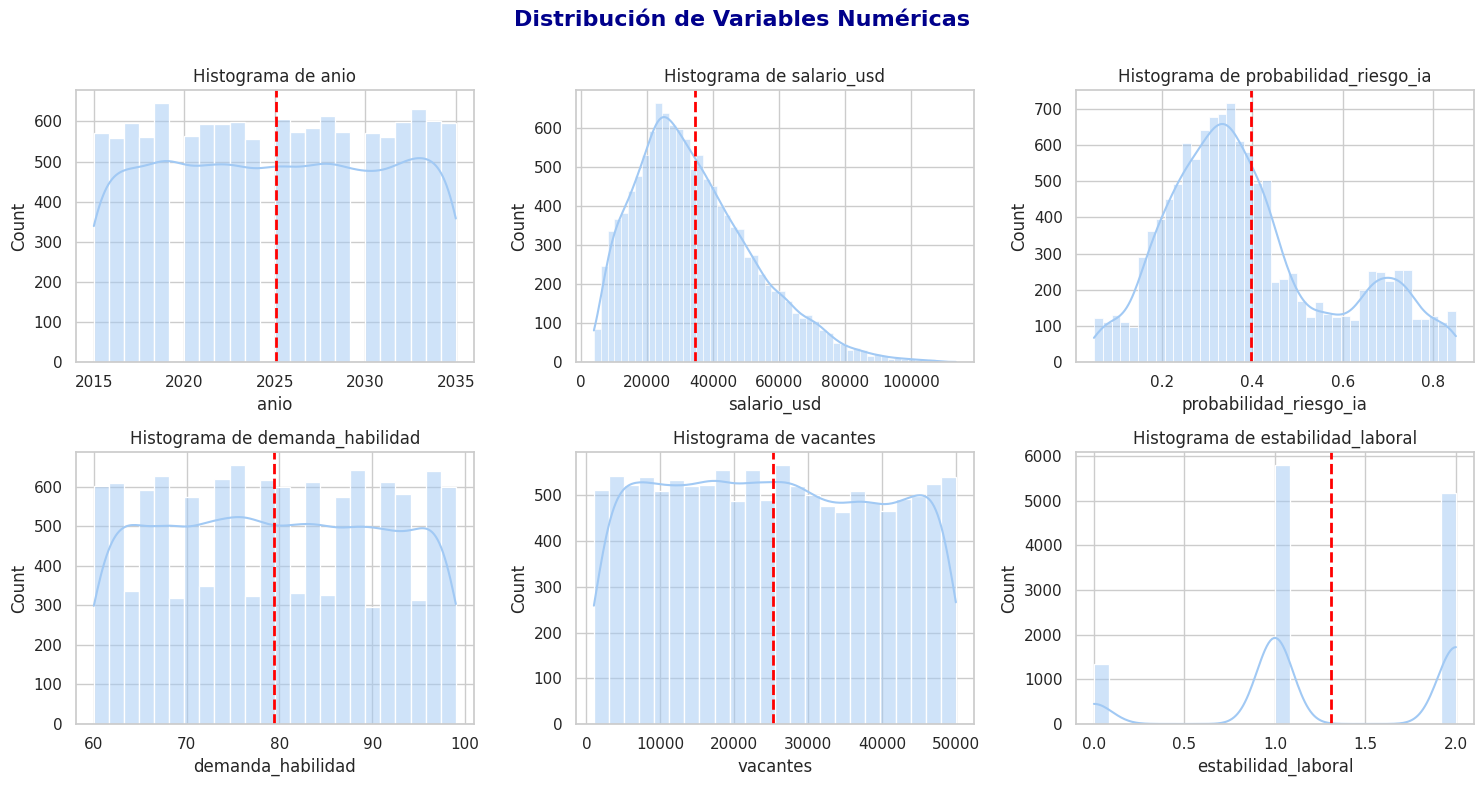

In [17]:
# columnas numéricas
cols = futuro_IA.select_dtypes(include=['int64', 'float64']).columns

# estilo
sns.set(style="whitegrid", palette="pastel")

# lienzo
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# histogramas
for i, col in enumerate(cols):
    media = futuro_IA[col].mean()

    sns.histplot(futuro_IA[col], kde=True, ax=axes[i])

    # línea de la media
    axes[i].axvline(media, color='red', linestyle='--', linewidth=2)

    axes[i].set_title(f'Histograma de {col}')

# título general centrado
fig.suptitle(
    'Distribución de Variables Numéricas',
    fontsize=16,
    fontweight='bold',
    color='darkblue'
)

# ajustar layout
plt.tight_layout()

# espacio para el título
plt.subplots_adjust(top=0.88)

plt.show()

El análisis de las distribuciones revela que el mercado laboral estudiado presenta características heterogéneas, especialmente en términos salariales y de riesgo de automatización.

El salario muestra una distribución altamente sesgada, evidenciando una concentración de empleos en rangos medios con una minoría de roles altamente remunerados, lo que sugiere desigualdad en la estructura salarial.

Por otro lado, la probabilidad de riesgo por inteligencia artificial no presenta una distribución uniforme, sino que parece segmentarse en diferentes grupos de exposición, lo que indica que ciertos perfiles laborales están significativamente más vulnerables que otros.

En contraste, variables como la demanda de habilidades y las vacantes muestran comportamientos más homogéneos, lo que podría indicar una distribución más equilibrada en términos de oportunidades y requerimientos del mercado.

Existe una clara desigualdad en la distribución de los salarios, donde la mayoría de los empleos se concentran en niveles medios, mientras que un pequeño grupo alcanza remuneraciones significativamente superiores.

El riesgo de automatización no es uniforme entre los distintos roles, lo que evidencia la existencia de segmentos laborales con diferentes niveles de vulnerabilidad frente a la inteligencia artificial.

In [18]:
from scipy.stats import kstest

for col in cols:
    data = futuro_IA[col]

    # estandarizar
    data_std = (data - np.mean(data)) / np.std(data)

    stat, p = kstest(data_std, 'norm')

    print(f"\nVariable: {col}")
    print(f"Estadístico: {stat:.4f}")
    print(f"p-valor: {p:.4f}")

    if p > 0.05:
        print("→ Aproximadamente normal")
    else:
        print("→ No sigue distribución normal")


Variable: anio
Estadístico: 0.0812
p-valor: 0.0000
→ No sigue distribución normal

Variable: salario_usd
Estadístico: 0.0680
p-valor: 0.0000
→ No sigue distribución normal

Variable: probabilidad_riesgo_ia
Estadístico: 0.1103
p-valor: 0.0000
→ No sigue distribución normal

Variable: demanda_habilidad
Estadístico: 0.0697
p-valor: 0.0000
→ No sigue distribución normal

Variable: vacantes
Estadístico: 0.0574
p-valor: 0.0000
→ No sigue distribución normal

Variable: estabilidad_laboral
Estadístico: 0.2725
p-valor: 0.0000
→ No sigue distribución normal


Se realizaron pruebas de normalidad utilizando el test de Kolmogorov-Smirnov para evaluar la distribución de las variables numéricas.

Los resultados indican que todas las variables presentan p-valores inferiores a 0.05, lo que lleva a rechazar la hipótesis nula de normalidad. Esto implica que ninguna de las variables sigue una distribución normal.

Estos resultados son consistentes con el análisis visual previo mediante histogramas, donde se identificaron distribuciones sesgadas, uniformes o discretas, particularmente en variables como el salario, las vacantes y la demanda de habilidades.

Es importante destacar que la variable de estabilidad laboral, al ser de tipo discreto, no es adecuada para este tipo de pruebas, lo que refuerza la necesidad de seleccionar correctamente las técnicas estadísticas según la naturaleza de los datos.

Dado que las variables no siguen una distribución normal, el análisis posterior deberá basarse en métodos no paramétricos, como la correlación de Spearman, en lugar de técnicas que asumen normalidad como la correlación de Pearson.

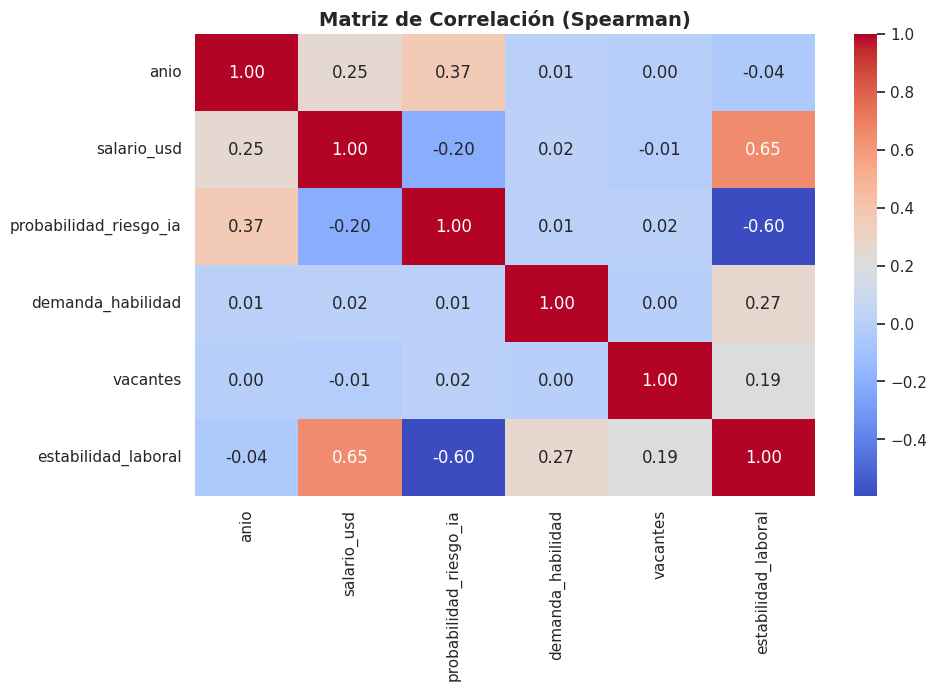

In [19]:
# seleccionar solo columnas numéricas
futuro_IA_num = futuro_IA.select_dtypes(include=['int64', 'float64'])

# correlación Spearman
corr = futuro_IA_num.corr(method='spearman')

# gráfico
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Matriz de Correlación (Spearman)", fontsize=14, fontweight='bold')
plt.show()

1. Salario vs Estabilidad laboral (0.65)

Existe una relación positiva fuerte entre el salario y la estabilidad laboral, lo que indica que los empleos mejor remunerados tienden a ofrecer mayor seguridad. Esto sugiere que el nivel salarial puede ser un indicador importante de la permanencia y solidez de un puesto de trabajo.

2. Salario vs Riesgo de IA (-0.20)

Se observa una relación negativa débil entre el salario y el riesgo de automatización, lo que indica que los empleos con mayores ingresos tienden a estar menos expuestos a ser reemplazados por inteligencia artificial, aunque esta relación no es determinante.

3. Riesgo de IA vs Estabilidad laboral (-0.60)

Existe una relación negativa fuerte entre el riesgo de automatización y la estabilidad laboral, evidenciando que los trabajos más expuestos a la inteligencia artificial presentan menores niveles de seguridad y mayor vulnerabilidad en el mercado laboral.

4. Demanda de habilidad vs Estabilidad laboral (0.27)

Se identifica una relación positiva moderada entre la demanda de habilidades y la estabilidad laboral, lo que sugiere que los empleos que requieren competencias más demandadas tienden a ser más estables en el tiempo.

5. Vacantes vs Estabilidad laboral (0.19)

La relación entre el número de vacantes y la estabilidad laboral es débilmente positiva, lo que indica que una mayor disponibilidad de empleos no necesariamente garantiza mayor seguridad laboral.

6. Salario vs Demanda de habilidad (0.02)

No se evidencia una relación significativa entre el salario y la demanda de habilidades, lo que sugiere que una mayor demanda de una habilidad no implica necesariamente una mejor remuneración.

7. Vacantes vs Salario (-0.01)

No existe una relación significativa entre el número de vacantes y el salario, lo que indica que la cantidad de oportunidades disponibles no está directamente asociada con el nivel de ingresos.


8. Demanda de habilidad vs Riesgo de IA (0.01)

No se observa una relación relevante entre la demanda de habilidades y el riesgo de automatización, lo que sugiere que una habilidad demandada no necesariamente está protegida frente al avance de la inteligencia artificial.

Las variables con mayor impacto en el mercado laboral son el salario, la estabilidad laboral y el riesgo de automatización por inteligencia artificial.

Estas variables presentan las relaciones más significativas dentro del análisis, evidenciando que los empleos mejor remunerados tienden a ser más estables y menos susceptibles a ser reemplazados por tecnologías emergentes.

Por otro lado, el riesgo de automatización se posiciona como un factor determinante en la seguridad del empleo, afectando directamente la estabilidad laboral.

En contraste, variables como la demanda de habilidades y el número de vacantes muestran una menor influencia en las dinámicas principales del mercado, lo que sugiere que la cantidad de oportunidades disponibles no es el factor más relevante al momento de evaluar la calidad o seguridad de un empleo.

En conjunto, estos hallazgos permiten concluir que el mercado laboral no solo está determinado por la disponibilidad de empleos, sino por la combinación entre remuneración, estabilidad y nivel de exposición a la automatización.

.....

/tmp/ipykernel_722/112973226.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=futuro_IA, y=col, order=orden, ax=axes[i], palette="Set2")
/tmp/ipykernel_722/112973226.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=futuro_IA, y=col, order=orden, ax=axes[i], palette="Set2")
/tmp/ipykernel_722/112973226.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=futuro_IA, y=col, order=orden, ax=axes[i], palette="Set2")
/tmp/ipykernel_722/112973226.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecate

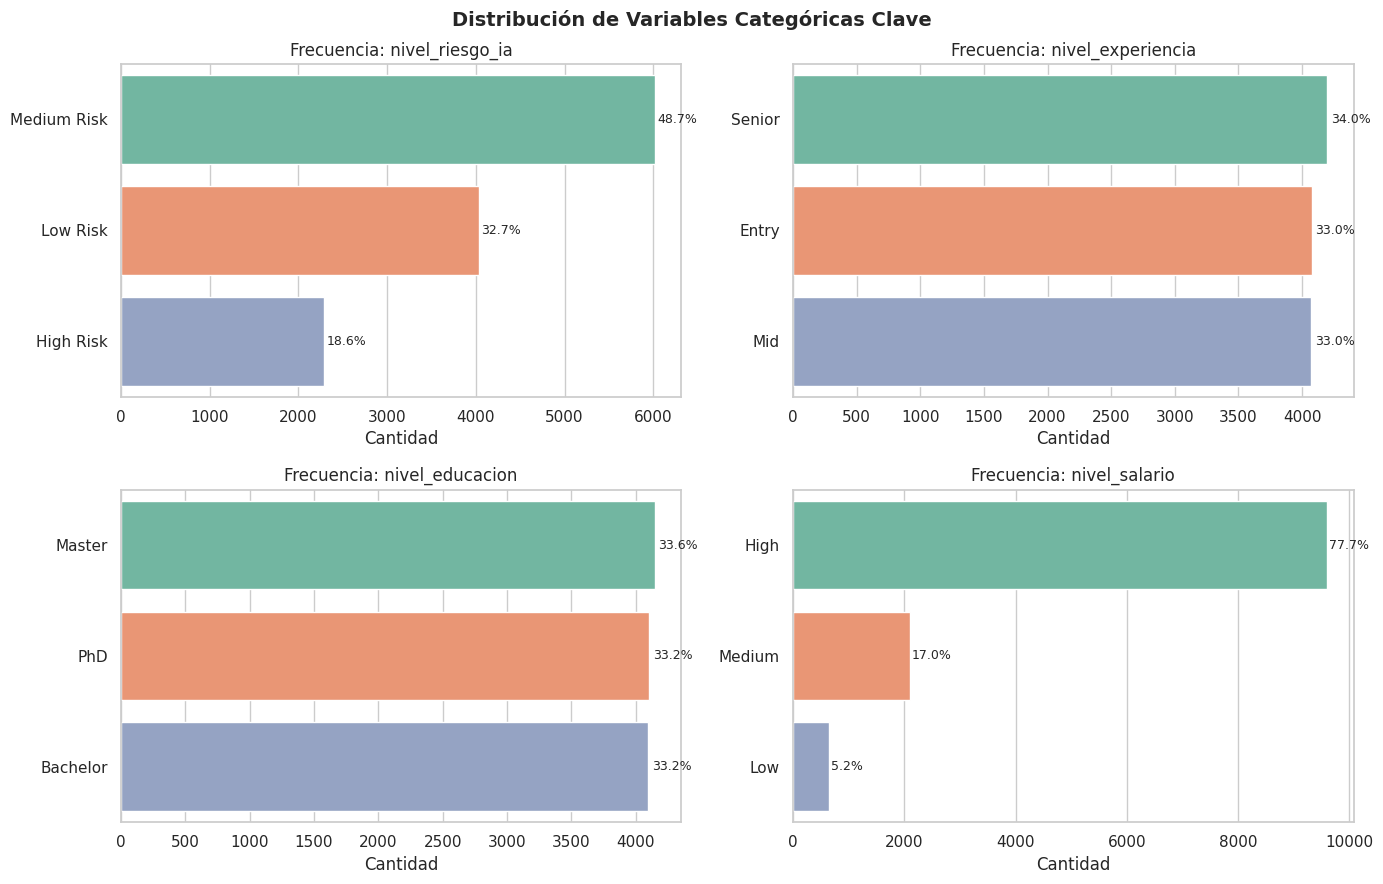

In [20]:
# Frecuencias de las principales variables categóricas
cat = ["nivel_riesgo_ia", "nivel_experiencia", "nivel_educacion", "nivel_salario"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cat):
    orden = futuro_IA[col].value_counts().index
    sns.countplot(data=futuro_IA, y=col, order=orden, ax=axes[i], palette="Set2")
    axes[i].set_title(f"Frecuencia: {col}")
    axes[i].set_xlabel("Cantidad")
    axes[i].set_ylabel("")
    # Añadir etiquetas de porcentaje
    total = len(futuro_IA)
    for p in axes[i].patches:
        pct = f"{100 * p.get_width() / total:.1f}%"
        axes[i].text(p.get_width() + 30, p.get_y() + p.get_height() / 2, pct, va="center", fontsize=9)

fig.suptitle("Distribución de Variables Categóricas Clave", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

La variable objetivo nivel_riesgo_ia presenta una mayor concentración en la categoría de riesgo medio, seguida por riesgo bajo y, en menor proporción, riesgo alto, lo que indica que la mayoría de los empleos podrían verse moderadamente afectados por la automatización. El nivel de experiencia y el nivel educativo muestran distribuciones bastante uniformes entre sus categorías, lo cual es adecuado para el análisis al evitar sesgos significativos. En contraste, la variable nivel_salario evidencia un desbalance importante, con una fuerte predominancia del nivel alto frente a los niveles medio y bajo, lo que sugiere una posible concentración de empleos mejor remunerados.

## Feature Engineering

###Variable: nivel_laboral

Codificamos nivel_experienci y nivel_educacion como variables ordinales y las sumamos para obtener un **índice de perfil profesional**.

| Experiencia | Valor | Educación | Valor |
|---|---|---|---|
| Entry | 1 | High School | 1 |
| Mid | 2 | Bachelor | 2 |
| Senior | 3 | Master | 3 |
| — | — | PhD | 4 |

`nivel_laboral = exp_num + edu_num` → rango de **3 a 7**

In [21]:
# Mapeos ordinales
map_exp = {"Entry": 1, "Mid": 2, "Senior": 3}
map_edu = {"High School": 1, "Bachelor": 2, "Master": 3, "PhD": 4}

futuro_IA["exp_num"] = futuro_IA["nivel_experiencia"].map(map_exp)
futuro_IA["edu_num"] = futuro_IA["nivel_educacion"].map(map_edu)
futuro_IA["nivel_laboral"] = futuro_IA["exp_num"] + futuro_IA["edu_num"]

print("Distribución de nivel_laboral:")
display(futuro_IA["nivel_laboral"].value_counts().sort_index().to_frame("conteo"))

print(f"\nRango: {futuro_IA['nivel_laboral'].min()} – {futuro_IA['nivel_laboral'].max()}")
print(f"Media: {futuro_IA['nivel_laboral'].mean():.2f}")


Distribución de nivel_laboral:


,conteo
nivel_laboral,
3,1392
4,2693
5,4060
6,2788
7,1410



Rango: 3 – 7
Media: 5.01


/tmp/ipykernel_722/1759132055.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=futuro_IA, x="nivel_laboral", palette="Blues_d", ax=axes[0])
/tmp/ipykernel_722/1759132055.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=futuro_IA, x="estabilidad_laboral", y="nivel_laboral",palette="Set2", ax=axes[1])


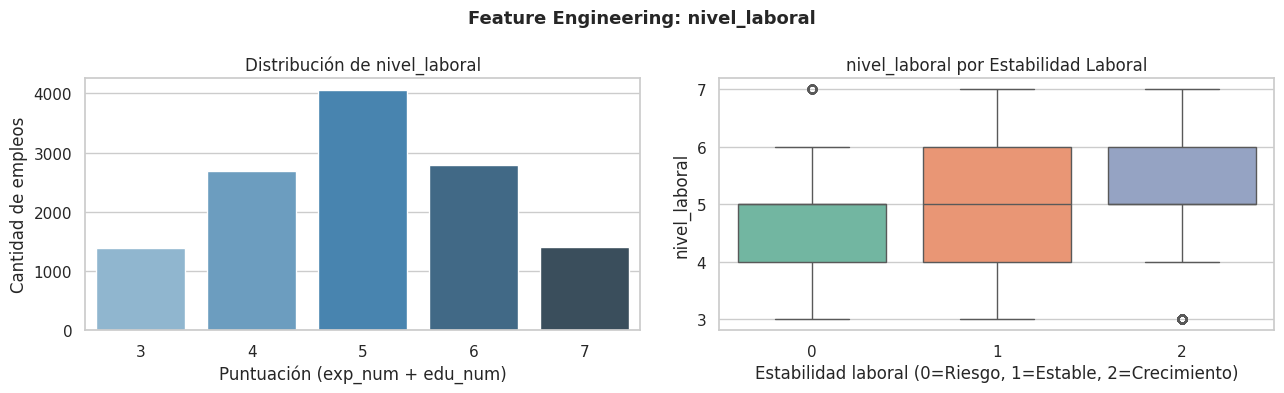

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución de nivel_laboral
sns.countplot(data=futuro_IA, x="nivel_laboral", palette="Blues_d", ax=axes[0])
axes[0].set_title("Distribución de nivel_laboral")
axes[0].set_xlabel("Puntuación (exp_num + edu_num)")
axes[0].set_ylabel("Cantidad de empleos")

# nivel_laboral vs estabilidad laboral
sns.boxplot(data=futuro_IA, x="estabilidad_laboral", y="nivel_laboral",palette="Set2", ax=axes[1])
axes[1].set_title("nivel_laboral por Estabilidad Laboral")
axes[1].set_xlabel("Estabilidad laboral (0=Riesgo, 1=Estable, 2=Crecimiento)")

plt.suptitle("Feature Engineering: nivel_laboral", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

La variable nivel_laboral, construida a partir de la combinación del nivel de experiencia y educación, presenta una mayor concentración en valores intermedios, especialmente alrededor de la puntuación 5, lo que indica que predominan perfiles con un equilibrio entre formación y experiencia. Los niveles más bajos y más altos tienen menor representación, sugiriendo que hay menos casos de perfiles muy junior o altamente especializados.

En relación con la estabilidad laboral, se observa una tendencia creciente del nivel_laboral a medida que mejora la estabilidad (de riesgo a crecimiento), lo que indica que los perfiles con mayor puntuación tienden a estar asociados con empleos más estables o con mejores perspectivas. Sin embargo, también se evidencia cierta dispersión dentro de cada categoría, lo que sugiere que la estabilidad laboral no depende exclusivamente del nivel laboral, sino que puede estar influenciada por otros factores adicionales

In [23]:
# Ratio de eficiencia
futuro_IA["ratio_eficiencia"] = futuro_IA["salario_usd"] / futuro_IA["vacantes"].replace(0, np.nan)

print("Estadísticas del ratio de eficiencia:")
display(futuro_IA["ratio_eficiencia"].describe().to_frame())

Estadísticas del ratio de eficiencia:


,ratio_eficiencia
count,12343.000000
mean,2.784532
std,4.703355
min,0.078749
25%,0.770741
50%,1.348269
75%,2.684551
max,76.536816


El ratio_eficiencia indica cuántos USD de salario corresponden a cada vacante disponible. Un ratio alto significa que hay pocas vacantes pero bien remuneradas (roles especializados y escasos), mientras que un ratio bajo implica muchas vacantes con salarios relativamente bajos (roles masivos y menos exclusivos).

/tmp/ipykernel_722/3823739710.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=futuro_IA, x="nivel_riesgo_ia",


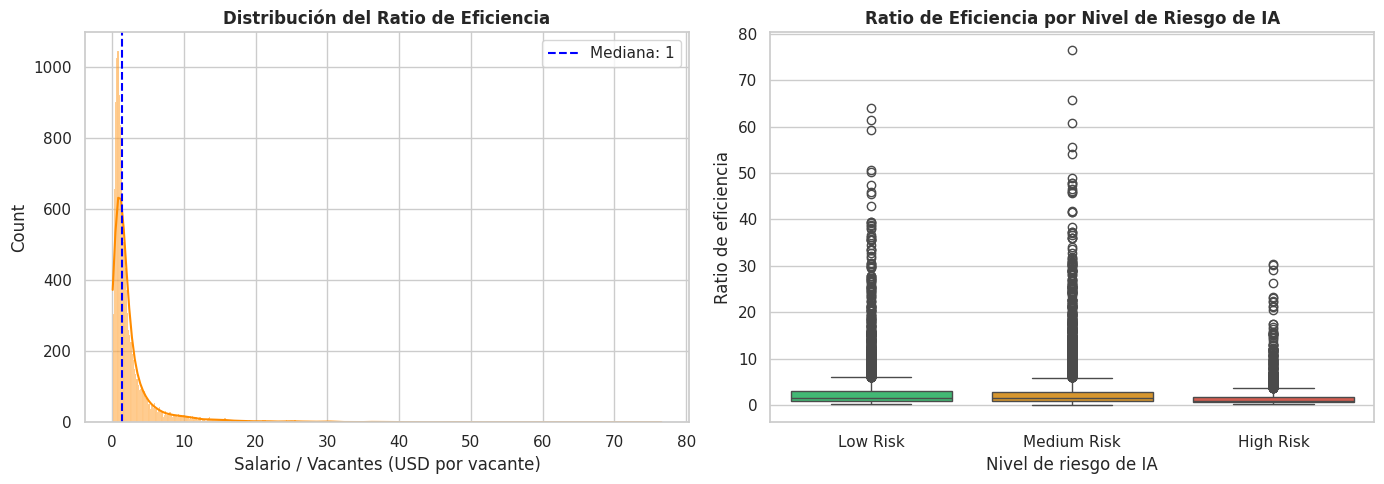

In [24]:
# Distribución del ratio de eficiencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
sns.histplot(futuro_IA["ratio_eficiencia"], kde=True, ax=axes[0], color="darkorange")
axes[0].axvline(futuro_IA["ratio_eficiencia"].median(), color="blue", linestyle="--",
                label=f"Mediana: {futuro_IA['ratio_eficiencia'].median():,.0f}")
axes[0].set_title("Distribución del Ratio de Eficiencia", fontweight="bold")
axes[0].set_xlabel("Salario / Vacantes (USD por vacante)")
axes[0].legend()

# Por nivel de riesgo de IA
sns.boxplot(data=futuro_IA, x="nivel_riesgo_ia",
            y="ratio_eficiencia",
            order=["Low Risk", "Medium Risk", "High Risk"],
            ax=axes[1],
            palette=["#2ecc71", "#f39c12", "#e74c3c"])
axes[1].set_title("Ratio de Eficiencia por Nivel de Riesgo de IA", fontweight="bold")
axes[1].set_xlabel("Nivel de riesgo de IA")
axes[1].set_ylabel("Ratio de eficiencia")

plt.tight_layout()
plt.show()

Un ratio de eficiencia más alto en empleos con bajo riesgo de IA sugiere que los trabajos más exclusivos y bien remunerados (con pocas vacantes) tienden a estar menos expuestos a la automatización, mientras que roles masivos y menos remunerados son más vulnerables.

In [25]:
# Normalizar probabilidad_riesgo_ia a rango [0, 1]
riesgo_min = futuro_IA["probabilidad_riesgo_ia"].min()
riesgo_max = futuro_IA["probabilidad_riesgo_ia"].max()
futuro_IA["riesgo_norm"] = (futuro_IA["probabilidad_riesgo_ia"] - riesgo_min) / (riesgo_max - riesgo_min)

# Normalizar nivel_laboral a rango [0, 1]
nivel_min = futuro_IA["nivel_laboral"].min()
nivel_max = futuro_IA["nivel_laboral"].max()
futuro_IA["nivel_norm"] = (futuro_IA["nivel_laboral"] - nivel_min) / (nivel_max - nivel_min)

# Índice de vulnerabilidad:
# Alto riesgo de IA (riesgo_norm alto) + Bajo nivel laboral (1 - nivel_norm alto)
# Se pondera con 60% al riesgo de IA y 40% al nivel laboral
futuro_IA["indice_vulnerabilidad"] = 0.6 * futuro_IA["riesgo_norm"] + 0.4 * (1 - futuro_IA["nivel_norm"])

print("Estadísticas del índice de vulnerabilidad:")
display(futuro_IA["indice_vulnerabilidad"].describe().to_frame())

Estadísticas del índice de vulnerabilidad:


,indice_vulnerabilidad
count,12343.000000
mean,0.458445
std,0.182757
min,0.000000
25%,0.325000
50%,0.442500
75%,0.580000
max,1.000000


El indice_vulnerabilidad oscila entre 0 y 1. Un valor cercano a 1 indica alta vulnerabilidad (mucho riesgo de ser reemplazado por IA + perfil laboral débil), mientras que un valor cercano a 0 indica baja vulnerabilidad (poco riesgo + perfil laboral fuerte)

In [26]:
futuro_IA.head()

,puesto_trabajo,pais,nivel_experiencia,nivel_educacion,anio,salario_usd,probabilidad_riesgo_ia,habilidad_principal,demanda_habilidad,vacantes,estabilidad_laboral,nivel_salario,nivel_riesgo_ia,exp_num,edu_num,nivel_laboral,ratio_eficiencia,riesgo_norm,nivel_norm,indice_vulnerabilidad
0,Data Scientist,USA,Senior,Master,2022,61931.03,0.32,Python,88,39158,2,High,Medium Risk,3,3,6,1.581568,0.3375,0.75,0.3025
1,Software Engineer,India,Senior,Bachelor,2032,21330.84,0.52,Java,80,7265,1,High,Medium Risk,3,2,5,2.936110,0.5875,0.50,0.5525
2,Data Scientist,Canada,Mid,Bachelor,2015,24211.17,0.25,Python,70,22962,1,High,Low Risk,2,2,4,1.054402,0.2500,0.25,0.4500
3,Data Scientist,India,Entry,PhD,2034,11794.86,0.44,Python,95,17023,1,Medium,Medium Risk,1,4,5,0.692878,0.4875,0.50,0.4925
4,Data Analyst,Canada,Entry,PhD,2035,17999.26,0.75,SQL,61,3433,0,Medium,High Risk,1,4,5,5.243012,0.8750,0.50,0.7250


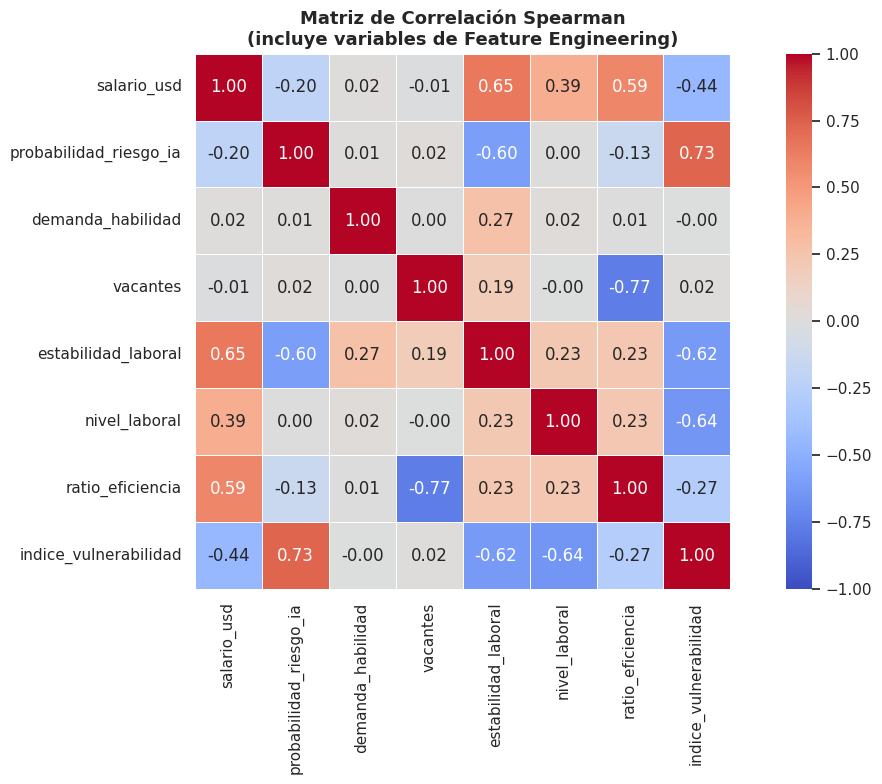

In [27]:
# Variables numéricas incluyendo las nuevas
vars_corr = [
    "salario_usd", "probabilidad_riesgo_ia", "demanda_habilidad",
    "vacantes", "estabilidad_laboral",
    "nivel_laboral", "ratio_eficiencia", "indice_vulnerabilidad"
]

# Matriz de correlación Spearman
corr_matrix = futuro_IA[vars_corr].corr(method="spearman")

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Solo triángulo inferior
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Matriz de Correlación Spearman\n(incluye variables de Feature Engineering)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

1. Salario vs Estabilidad laboral (0.65)
Existe una relación positiva fuerte entre el salario y la estabilidad laboral, lo que indica que los empleos mejor remunerados tienden a ser más estables. Esto sugiere que el nivel salarial puede ser un buen indicador de seguridad laboral.

2. Salario vs Ratio de eficiencia (0.59)
Se observa una relación positiva moderada entre el salario y el ratio de eficiencia, lo que indica que los empleos con mayores ingresos tienden a generar mayor valor en función de las vacantes disponibles.

3. Salario vs Índice de vulnerabilidad (-0.44)
Existe una relación negativa moderada, lo que sugiere que los empleos mejor pagados tienden a ser menos vulnerables, posiblemente por requerir habilidades más especializadas o difíciles de automatizar.

4. Riesgo de IA vs Índice de vulnerabilidad (0.73)
Se evidencia una relación positiva fuerte, indicando que a mayor riesgo de automatización, mayor es la vulnerabilidad del empleo. Esto refuerza la idea de que la IA impacta directamente en la estabilidad de ciertos perfiles laborales.

5. Riesgo de IA vs Estabilidad laboral (-0.60)
Existe una relación negativa fuerte, lo que indica que los empleos con mayor riesgo de automatización tienden a ser menos estables y más propensos a cambios o desaparición.

6. Vacantes vs Ratio de eficiencia (-0.77)
Se observa una relación negativa fuerte, lo que sugiere que a mayor número de vacantes, menor es la eficiencia en términos de generación de salario, posiblemente por saturación o menor especialización en esos roles.

7. Nivel laboral vs Índice de vulnerabilidad (-0.64)
Existe una relación negativa fuerte, indicando que a mayor nivel laboral (más experiencia y educación), menor es la vulnerabilidad frente al mercado laboral y la automatización.

8. Estabilidad laboral vs Índice de vulnerabilidad (-0.62)
Se evidencia una relación negativa fuerte, lo que sugiere que los empleos más estables tienden a ser menos vulnerables, reforzando la conexión entre seguridad laboral y menor exposición al riesgo.

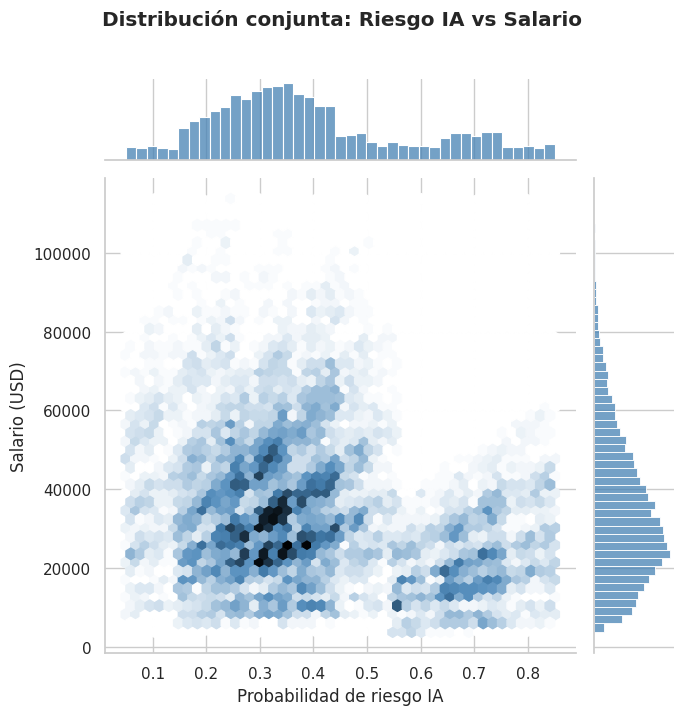

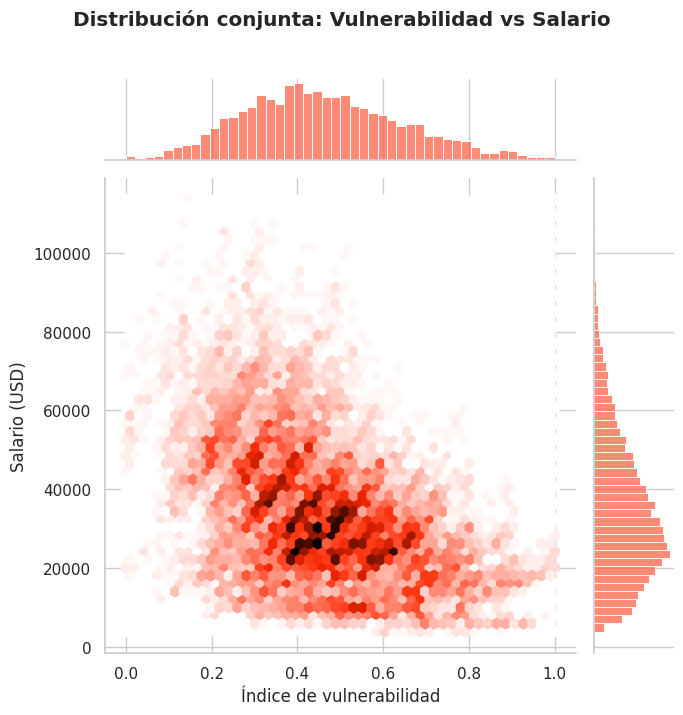

In [28]:
# Histogramas conjuntos para dos relaciones clave

# 1. Probabilidad de riesgo IA vs Salario
g1 = sns.jointplot(
    data=futuro_IA,
    x="probabilidad_riesgo_ia",
    y="salario_usd",
    kind="hex",
    height=7,
    color="steelblue"
)
g1.set_axis_labels("Probabilidad de riesgo IA", "Salario (USD)")
g1.figure.suptitle("Distribución conjunta: Riesgo IA vs Salario",
                    fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# 2. Índice de vulnerabilidad vs Salario
g2 = sns.jointplot(
    data=futuro_IA,
    x="indice_vulnerabilidad",
    y="salario_usd",
    kind="hex",
    height=7,
    color="tomato"
)
g2.set_axis_labels("Índice de vulnerabilidad", "Salario (USD)")
g2.figure.suptitle("Distribución conjunta: Vulnerabilidad vs Salario",
                    fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Se puede notar que la mayor parte de los datos se concentra en niveles medios de riesgo de IA y salarios intermedios. No se ve una relación completamente clara o lineal entre el riesgo y el salario, pero sí se alcanza a percibir una ligera tendencia en la que, a medida que aumenta el riesgo de automatización, los salarios tienden a ser más bajos.

También se observa bastante dispersión en los datos, lo que indica que no todos los empleos siguen el mismo patrón. Es decir, hay trabajos con salarios medios o incluso altos que aún presentan cierto nivel de riesgo, lo que sugiere que el salario no depende únicamente del riesgo de IA.

En general, el gráfico muestra que existe una relación débil entre ambas variables, donde el riesgo de automatización influye en el salario, pero no lo determina completamente

# **PREPROCESAMIENTO** #

Luego del análisis exploratorio (EDA) y del feature engineering, pasamos a la etapa de preprocesamiento. El objetivo es transformar el dataset en un formato adecuado para entrenar modelos de ML

## Verificación e Imputación de Valores FaltanteS

Aunque en el EDA verificamos que el dataset original no tenía valores nulos, el feature engineering pudo haber generado "NaN" en variables nuevas. Por ejemplo, ratio_eficiencia se calculó dividiendo el salario entre las vacantes, y cuando vacantes = 0 el resultado fue "NaN"

Por eso revisamos nuevamente el estado completo del dataset antes de continuar.

In [29]:
# Verificar valores faltantes en el dataset completo (incluye variables nuevas)
futuro_IA.isnull().sum()


,0
puesto_trabajo,0
pais,0
nivel_experiencia,0
nivel_educacion,0
anio,0
salario_usd,0
probabilidad_riesgo_ia,0
habilidad_principal,0
demanda_habilidad,0
vacantes,0


Se verificó que el dataset no presenta valores faltantes tras el feature engineering, por lo que no es necesario aplicar ningún método de imputación



## **Codificación de Variables Categóricas** ##

Los modelos de ML trabajan con números, no con texto. Por eso las variables categóricas deben convertirse a representaciones numéricas.

Identificamos los siguientes casos en el dataset:

**nivel_experiencia:** Ordinal. Ya codificada como "exp_num" (realizado en el feature engineering)

**nivel_educacion:** Ordianl. Ya codificada como "edu_num" (realizado en el feature engineering)

**nivel_riesgo_ia:** Ordinal (Low Risk - Medium Risk - High Risk) - *OrdinalEncoder*

**nivel_salario:** Ordinal (Low - Medium - High) - *OrdinalEncoder*

**pais, puesto_trabajo, habilidad_principal:** Nominal. Verificar cuántas categorías únicas tiene cada variable antes de decidir qué hacer con ellas


### OrdinalEncoder — nivel_riesgo_ia

La variable nivel_riesgo_ia tiene un orden natural claro: *Low Risk - Medium Risk - High Risk*

Usamos *OrdinalEncoder* especificando explícitamente el orden de las categorías para que el modelo interprete correctamente la jerarquía.

**¿Por qué no LabelEncoder?** LabelEncoder asigna números en orden alfabético sin respetar el orden lógico

In [30]:
# Codificación ordinal de nivel_riesgo_ia con el orden correcto
enc_ordinal = OrdinalEncoder(
    categories=[["Low Risk", "Medium Risk", "High Risk"]]
)

futuro_IA["nivel_riesgo_ia_enc"] = enc_ordinal.fit_transform(
    futuro_IA[["nivel_riesgo_ia"]]
)

# Mostrar lo aplicado
print("Mapeo de nivel_riesgo_ia:")
for cat, val in zip(enc_ordinal.categories_[0], [0, 1, 2]):
    print(f"  {cat} → {int(val)}")

print("\nPrimeras filas con la nueva codificación:")
display(futuro_IA[["nivel_riesgo_ia", "nivel_riesgo_ia_enc"]].head())

Mapeo de nivel_riesgo_ia:
  Low Risk → 0
  Medium Risk → 1
  High Risk → 2

Primeras filas con la nueva codificación:


,nivel_riesgo_ia,nivel_riesgo_ia_enc
0,Medium Risk,1.0
1,Medium Risk,1.0
2,Low Risk,0.0
3,Medium Risk,1.0
4,High Risk,2.0


La variable nivel_salario tambien tiene un orden natural claro: *Low - Medium - High* por ende tambien usamos *OrdinalEncoder*


In [31]:
# Codificación ordinal de nivel_salario con el orden correcto
enc_salario = OrdinalEncoder(
    categories=[["Low", "Medium", "High"]]
)

futuro_IA["nivel_salario_enc"] = enc_salario.fit_transform(
    futuro_IA[["nivel_salario"]]
)

# Mostrar lo aplicado
print("Mapeo de nivel_salario:")
for cat, val in zip(enc_salario.categories_[0], [0, 1, 2]):
    print(f"  {cat} → {int(val)}")

print("\nPrimeras filas con la nueva codificación:")
display(futuro_IA[["nivel_salario", "nivel_salario_enc"]].head())

Mapeo de nivel_salario:
  Low → 0
  Medium → 1
  High → 2

Primeras filas con la nueva codificación:


,nivel_salario,nivel_salario_enc
0,High,2.0
1,High,2.0
2,High,2.0
3,Medium,1.0
4,Medium,1.0


In [32]:
#Verificar cuantas categorias unicas tiene

for col in ['pais', 'puesto_trabajo', 'habilidad_principal']:
    n = futuro_IA[col].nunique()
    print(f"{col}: {n} categorías únicas")

pais: 6 categorías únicas
puesto_trabajo: 10 categorías únicas
habilidad_principal: 9 categorías únicas


Como tiene pocas categorías se le puede aplicar **OneHotEncoder**

In [33]:
cols_ohe = ["pais", "puesto_trabajo", "habilidad_principal"]

enc_ohe = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")

ohe_result = enc_ohe.fit_transform(futuro_IA[cols_ohe])
ohe_cols   = enc_ohe.get_feature_names_out(cols_ohe)

df_ohe = pd.DataFrame(ohe_result, columns=ohe_cols, index=futuro_IA.index)

# Agregar al dataset
futuro_IA = pd.concat([futuro_IA, df_ohe], axis=1)

print(f"Columnas generadas por OneHotEncoder ({len(ohe_cols)}):")
for col in ohe_cols:
    print(f"  - {col}")

Columnas generadas por OneHotEncoder (22):
  - pais_Canada
  - pais_Germany
  - pais_India
  - pais_UK
  - pais_USA
  - puesto_trabajo_Business Analyst
  - puesto_trabajo_Cloud Engineer
  - puesto_trabajo_Cybersecurity Analyst
  - puesto_trabajo_Data Analyst
  - puesto_trabajo_Data Scientist
  - puesto_trabajo_DevOps Engineer
  - puesto_trabajo_ML Engineer
  - puesto_trabajo_Product Manager
  - puesto_trabajo_Software Engineer
  - habilidad_principal_Deep Learning
  - habilidad_principal_Docker
  - habilidad_principal_Excel
  - habilidad_principal_Java
  - habilidad_principal_Python
  - habilidad_principal_SQL
  - habilidad_principal_Security
  - habilidad_principal_Strategy


In [34]:
futuro_IA.describe()

,anio,salario_usd,probabilidad_riesgo_ia,demanda_habilidad,vacantes,estabilidad_laboral,exp_num,edu_num,nivel_laboral,ratio_eficiencia,...,puesto_trabajo_Product Manager,puesto_trabajo_Software Engineer,habilidad_principal_Deep Learning,habilidad_principal_Docker,habilidad_principal_Excel,habilidad_principal_Java,habilidad_principal_Python,habilidad_principal_SQL,habilidad_principal_Security,habilidad_principal_Strategy
count,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000,...,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000
mean,2025.054525,34553.729166,0.396008,79.453374,25223.652029,1.310054,2.009722,3.000891,5.010613,2.784532,...,0.101029,0.101434,0.097950,0.090578,0.106295,0.101434,0.196873,0.104756,0.097950,0.101029
std,6.058714,18024.702961,0.187665,11.483535,14163.309081,0.658417,0.818520,0.814957,1.162798,4.703355,...,0.301379,0.301915,0.297259,0.287019,0.308227,0.301915,0.397651,0.306251,0.297259,0.301379
min,2015.000000,3875.170000,0.050000,60.000000,1002.000000,0.000000,1.000000,2.000000,3.000000,0.078749,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020.000000,21331.405000,0.260000,70.000000,12993.000000,1.000000,1.000000,2.000000,4.000000,0.770741,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2025.000000,31573.380000,0.360000,79.000000,24896.000000,1.000000,2.000000,3.000000,5.000000,1.348269,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2030.000000,45307.845000,0.490000,89.000000,37440.500000,2.000000,3.000000,4.000000,6.000000,2.684551,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2035.000000,113589.260000,0.850000,99.000000,49998.000000,2.000000,3.000000,4.000000,7.000000,76.536816,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Escalado y normalización**

En el dataset hay variables como salario_usd que tienen valores muy grandes, mientras que otras como probabilidad_riesgo_ia tienen valores pequeños. Si no se escalan, el modelo puede darle más importancia al salario solo por su tamaño.

Para solucionar esto, se aplicó un proceso de escalado.

Método elegido: RobustScaler

Ya que este método usa la mediana y no se ve tan afectado por estos valores atípicos.

¿Por qué no se usaron otros métodos?

StandardScaler: usa la media, que se puede afectar mucho por outliers
MinMaxScaler: depende del valor mínimo y máximo, por lo que los valores extremos pueden distorsionar el resultado
MaxAbsScaler: se usa más en datos con muchos ceros (como texto), no en este caso
Normalizer: trabaja por filas y no por columnas, por lo que no es adecuado para este problema

Finalmente, las variables binarias (como las creadas con OneHotEncoding) y las variables ordinales no necesitan escalado, ya que ya están en rangos pequeños. Sin embargo, incluirlas no afecta significativamente el modelo.

In [40]:
cols_escalar = [
    "probabilidad_riesgo_ia",
    "demanda_habilidad",
    "vacantes",
    "salario_usd",
    "nivel_laboral",
    "ratio_eficiencia",
    "indice_vulnerabilidad",
    "nivel_riesgo_ia_enc",
    "nivel_salario_enc"
]

scaler = RobustScaler()
futuro_IA[cols_escalar] = scaler.fit_transform(futuro_IA[cols_escalar])

display(futuro_IA[cols_escalar].describe().round(3))

,probabilidad_riesgo_ia,demanda_habilidad,vacantes,salario_usd,nivel_laboral,ratio_eficiencia,indice_vulnerabilidad,nivel_riesgo_ia_enc,nivel_salario_enc
count,12343.000,12343.000,12343.000,12343.000,12343.000,12343.000,12343.000,12343.000,12343.000
mean,0.157,0.024,0.013,0.124,0.005,0.750,0.063,-0.141,-0.275
std,0.816,0.604,0.579,0.752,0.581,2.458,0.717,0.702,0.551
min,-1.348,-1.000,-0.977,-1.155,-1.000,-0.663,-1.735,-1.000,-2.000
25%,-0.435,-0.474,-0.487,-0.427,-0.500,-0.302,-0.461,-1.000,0.000
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.565,0.526,0.513,0.573,0.500,0.698,0.539,0.000,0.000
max,2.130,1.053,1.027,3.421,1.000,39.287,2.186,1.000,0.000


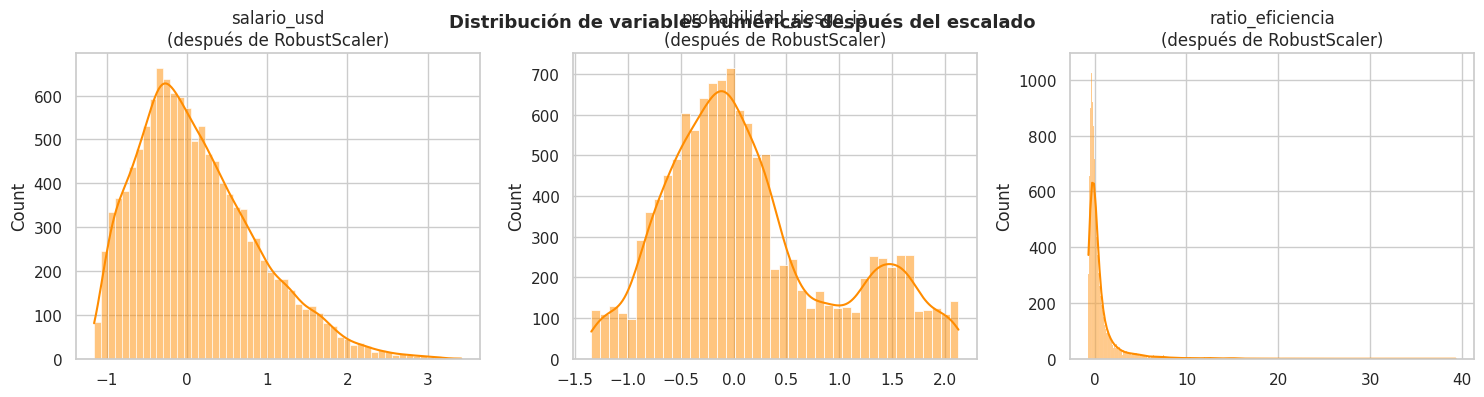

In [43]:
cols_visualizar = ["salario_usd", "probabilidad_riesgo_ia", "ratio_eficiencia"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(cols_visualizar):
    sns.histplot(futuro_IA[col], kde=True, ax=axes[i], color="darkorange")
    axes[i].set_title(f"{col}\n(después de RobustScaler)")
    axes[i].set_xlabel("")

fig.suptitle("Distribución de variables numéricas después del escalado",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

Las distribuciones después de aplicar RobustScaler confirman que el escalado fue aplicado correctamente. Los valores de todas las variables pasaron a una  escala comparable, manteniéndose la forma original de cada distribución.

**salario_usd**: Los valores quedaron centrados alrededor de 0, conservando
su distribución sesgada hacia la derecha, lo que indica la presencia de empleos con salarios significativamente superiores al promedio.

**probabilidad_riesgo_ia**: Se observa una distribución bimodal (dos picos),confirmando lo identificado en el EDA: existen dos grupos diferenciados de
empleos según su nivel de exposición a la automatización.

**ratio_eficiencia**: Presenta una cola muy larga hacia la derecha con valores extremos, lo que evidencia la presencia de outliers fuertes

In [46]:
# Aplicar PCA sobre los datos escalados
pca_full = PCA(random_state=42)
pca_full.fit(futuro_IA[cols_escalar])

# Calcular varianza acumulada
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)
n_componentes_95 = int(np.argmax(varianza_acumulada >= 0.95) + 1)

print("Varianza explicada por cada componente:")
for i, v in enumerate(pca_full.explained_variance_ratio_):
    acum = varianza_acumulada[i]
    print(f"  PC{i+1}: {v:.4f}  |  Acumulada: {acum:.4f}")

print(f"\n Se necesitan {n_componentes_95} componentes para retener el 95% de la varianza.")

Varianza explicada por cada componente:
  PC1: 0.6498  |  Acumulada: 0.6498
  PC2: 0.1613  |  Acumulada: 0.8111
  PC3: 0.0699  |  Acumulada: 0.8811
  PC4: 0.0380  |  Acumulada: 0.9190
  PC5: 0.0377  |  Acumulada: 0.9567
  PC6: 0.0233  |  Acumulada: 0.9800
  PC7: 0.0145  |  Acumulada: 0.9945
  PC8: 0.0055  |  Acumulada: 1.0000
  PC9: 0.0000  |  Acumulada: 1.0000

→ Se necesitan 5 componentes para retener el 95% de la varianza.


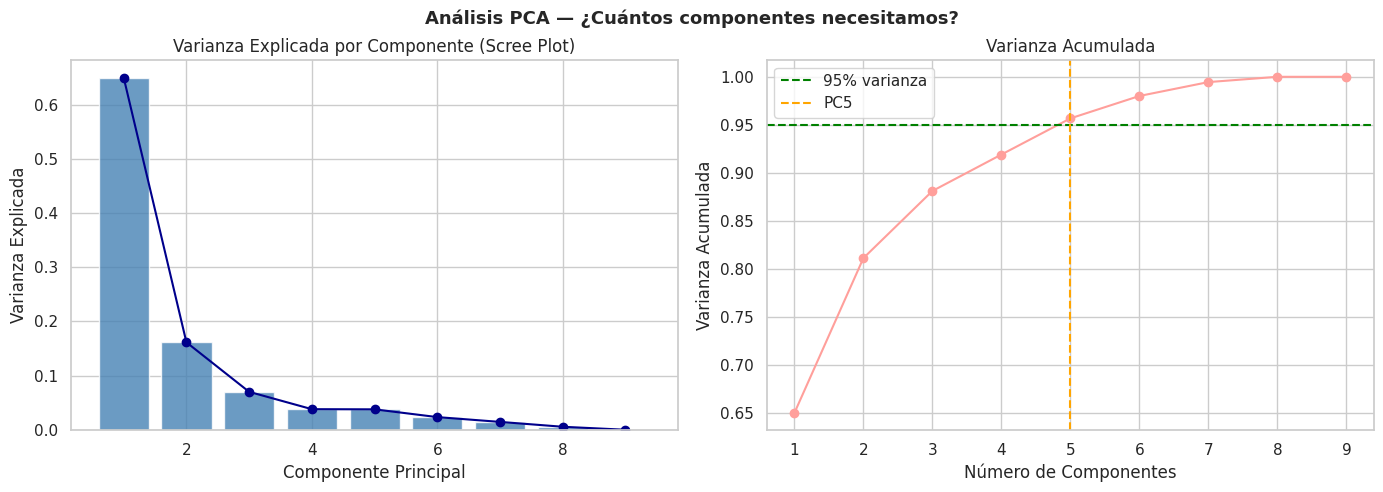

In [48]:
# Gráfico: Scree Plot + Varianza Acumulada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n = len(pca_full.explained_variance_ratio_)
x = range(1, n + 1)

axes[0].bar(x, pca_full.explained_variance_ratio_, color="steelblue", alpha=0.8)
axes[0].plot(x, pca_full.explained_variance_ratio_, "o-", color="darkblue")
axes[0].set_title("Varianza Explicada por Componente (Scree Plot)")
axes[0].set_xlabel("Componente Principal")
axes[0].set_ylabel("Varianza Explicada")

axes[1].plot(x, varianza_acumulada, "ro-")
axes[1].axhline(y=0.95, color="green", linestyle="--", label="95% varianza")
axes[1].axvline(x=n_componentes_95, color="orange", linestyle="--",
                label=f"PC{n_componentes_95}")
axes[1].set_title("Varianza Acumulada")
axes[1].set_xlabel("Número de Componentes")
axes[1].set_ylabel("Varianza Acumulada")
axes[1].legend()

fig.suptitle("Análisis PCA — ¿Cuántos componentes necesitamos?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()
